This notebook demonstrates the capabilities of the raytracer in computing attenuation and phase shifts, and uses this to create synthetic diffraction patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(enable_x64 = True)

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag
import processing.plotting as plots
import shared.domains as domains

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: C:\Users\qinal\OneDrive - Imperial College London\UROP\synthPy\src

Disabling python multi-threading...
Initialising jax...


Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19)]


<module 'processing.diagnostics' from 'C:\\Users\\qinal\\OneDrive - Imperial College London\\UROP\\synthPy\\src\\processing\\diagnostics.py'>

In [2]:
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3
lengths = 2 * np.array([extent_x, extent_y, extent_z])
probing_extent = extent_z
probing_direction = 'z'

divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

In [3]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
n_cells = 128

rho1 = np.full((n_cells, n_cells, n_cells), 1e3)
Te = np.full((n_cells, n_cells, n_cells), 2e3)

#domain = d.ScalarDomain(x = x, y = y, z = z, extent = probing_extent, probing_direction = probing_direction)     # create domain
# Much simpler domain function, no longer needlessly takes in beam values, they are fully seperated
domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=True, ne_0 = 1e27, Ly = extent_y*0.5, s = 2e-3) # B_on = False by default
#domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, inv_brems=True, Te = Te, Z = Z) # B_on = False by default

# load some external pvti
# import utils.handle_filetypes as load
# ne, dim, spacing = load.pvti_readin(filename)
# or load a test distribution

# only necessary to do so if you are not using the domain initialisation default distribution loading
# - that is the best option if using a test distribution

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 3.9408912658691406 GB
 - used  : 11.675506591796875 GB

Est. domain memory limit: 48.0 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


In [4]:
lwl = 0.1e-9 #define laser wavelength
Np = 100000    # number of photons

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

# domain.dim - this causes a TracerBoolConversionError
# passing r_n all individually works though
# also passing ScalarDomain and extracting dim in p.solve(...) causes the same issue
# issue is due to unkown value when assigned to diffrax

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)
# defaults: return_E = False, parallelise = True, jitted = True, save_points_per_region = 2, memory_debug = False, lwl = 1064e-9, keep_domain = False, return_raw_results = False


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 80.108642578125 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0 seconds
Completed ray trace in 33.04 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (100000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the for

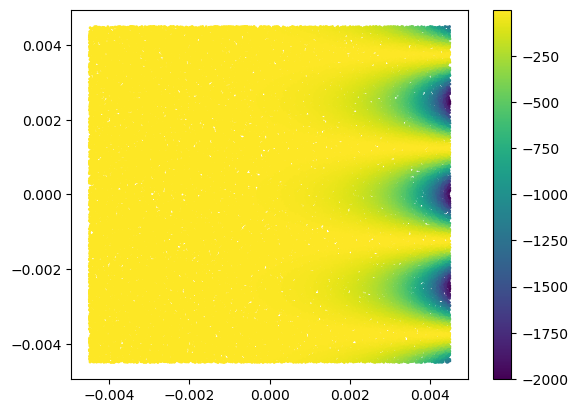

In [7]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()

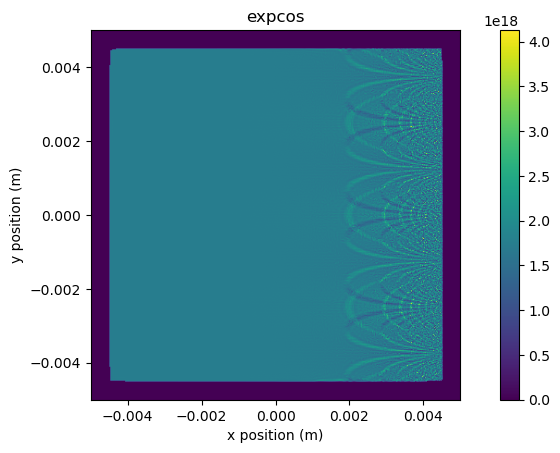

In [8]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 400, 400, "expcos", 0.1e-9)

In [22]:
n_cells = 200
ne = domains.turbulent_box(1e28, 9e27, 3, 2, 5, n_cells)
rho1 = np.full((n_cells, n_cells, n_cells), 1e3)
Te = np.full((n_cells, n_cells, n_cells), 2e3)

domain = d.ScalarDomain(lengths, n_cells, probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=True, ne = ne) # B_on = False by default

Predicted size in memory of domain: 30.517578125 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 5.64776611328125 GB
 - used  : 9.968631744384766 GB

Est. domain memory limit: 183.10546875 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (200, 200, 200) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


In [23]:
lwl = 0.1e-9 #define laser wavelength
Np = 50000    # number of photons


beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type)
rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 40.0543212890625 MB
 --> Np = 50000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.0023043155670166016 seconds
Completed ray trace in 144.69 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (50000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and tran

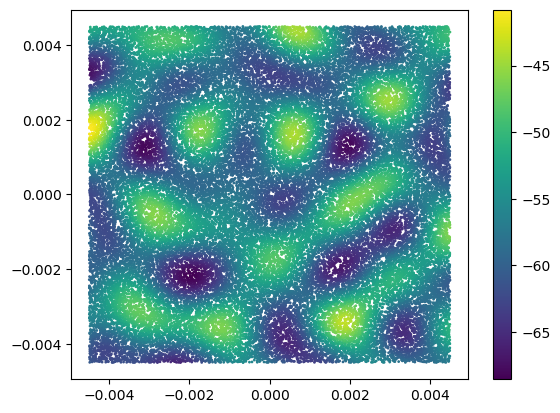

In [24]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()


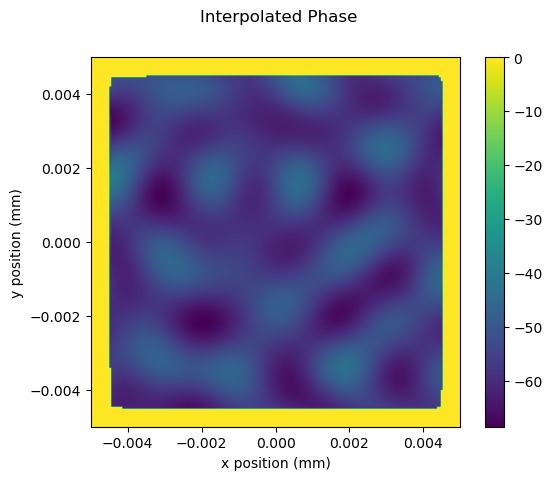

In [25]:
plots.interpolated_phase(domain, rf[0], rf[2], rf[5], 200, 200, wrapped = False)

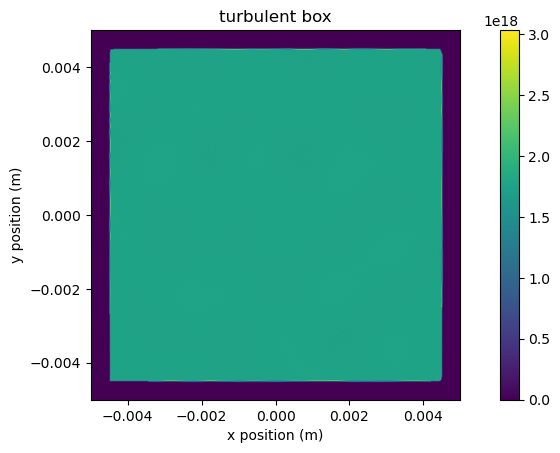

In [29]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 800, 800, "turbulent box", 0.1e-9)

In [13]:
radii = (2e-3, 3e-3,4e-3)
e_densities = (1e27, 1e28, 6e28)
m_densities = (0.3, 3.5e3, 3.5e3)
n_cells = 200
Te = np.full((n_cells, n_cells, n_cells), 2e3)
opacity_files = ("opa_DT_NLTE_Full_linear1000.spk", "opa_C_NLTE_Full_linear1000.spk", "opa_CH_NLTE_Full_linear1000.spk")
ne, densities = domains.spherical(radii, e_densities, m_densities, lengths, n_cells)
domain = d.ScalarDomain(lengths, n_cells, probing_direction = probing_direction, 
                        opacity = True, num_materials=3, densities = densities, Te = Te, 
                        opacity_files=opacity_files, phaseshift=True, ne = ne) 


Predicted size in memory of domain: 30.517578125 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 2.97613525390625 GB
 - used  : 12.640262603759766 GB

Est. domain memory limit: 183.10546875 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (200, 200, 200) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


In [14]:
lwl = 0.1e-9 #define laser wavelength

# initialise beam
Np = 50000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type)
rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent, lwl = lwl)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 40.0543212890625 MB
 --> Np = 50000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.001032114028930664 seconds
Completed ray trace in 153.467 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (50000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and tran

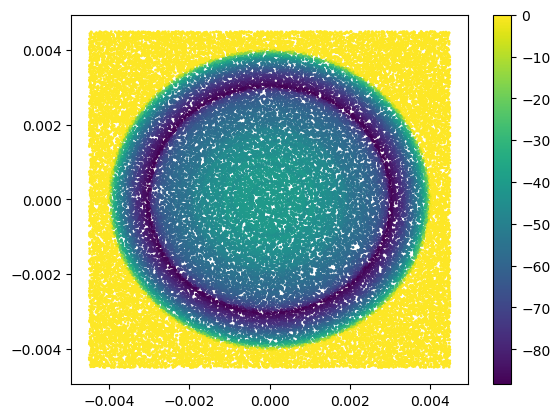

In [15]:
plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()

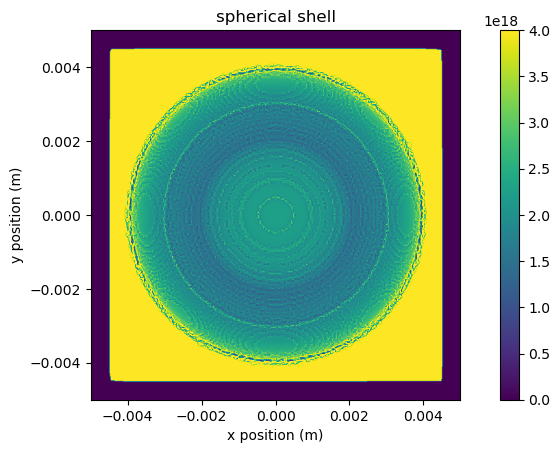

In [20]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 800, 800, "spherical shell", 0.1e-9, vmax = 4e18)